<a href="https://colab.research.google.com/github/thaysfaleiro-a11y/Mini-projeto-SCTEC/blob/main/Projeto_avaliativo_M%C3%B3dulo_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Projeto Avaliativo - Módulo 1: Pipeline Preditivo para a Indústria 4.0**

## **1. Introdução e Definição do Problema**

O presente projeto apresenta o desenvolvimento e a estruturação de um **Pipeline Preditivo completo de Machine Learning** aplicado ao contexto da Indústria 4.0.


**O Problema de Negócio:**  
O objetivo principal consiste em monitorar um parque fabril por meio de sensores industriais para prever quebras mecânicas nos equipamentos, evitando paradas não planejadas na linha de produção e minimizando prejuízos operacionais.


**A Variável Alvo:**  
A variável alvo do projeto é binária e está estruturada da seguinte forma:
* **Falha = 1:** Avaria mecânica detectada no equipamento.
* **Falha = 0:** Equipamento em funcionamento normal.

---


#Célula 1: Configuração, Autenticação e Carga dos Dados

Preparação do Ambiente e Carga dos Dados

Nesta etapa inicial, realiza-se a configuração do ambiente de desenvolvimento no Google Colab. O processo envolve a importação das bibliotecas essenciais para manipulação de dados, visualização gráfica e modelagem preditiva, além da autenticação segura para extração dos dados diretamente do Google Sheets.

Etapas executadas:
Importação de Bibliotecas: Carregamento do pandas e numpy para processamento matemático, seaborn e matplotlib para geração de gráficos, e módulos do scikit-learn e imblearn para estruturação dos modelos de Machine Learning.

Autenticação de Segurança: Conexão com o ecossistema Google para permissão de leitura da planilha.

Carga e Inicialização: Conexão com o arquivo 'manutencao_preditivaa333' e conversão dos dados brutos em um objeto estruturado do tipo DataFrame.

In [154]:
# ==============================================================================
# CÉLULA 1: CONFIGURAÇÃO, AUTENTICAÇÃO E CARGA DOS DADOS
# ==============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings('ignore')

# Autenticação no Google Colab para acessar o Google Sheets
from google.colab import auth
import gspread
from google.auth import default

auth.authenticate_user()
creds, _ = default()
gc = gspread.authorize(creds)

# Abertura da planilha
nome_da_planilha = 'manutencao_preditivaa333'
planilha = gc.open(nome_da_planilha)
aba = planilha.sheet1
dados = aba.get_all_values()

# Criação do DataFrame original
df = pd.DataFrame(dados[1:], columns=dados[0])
df.head()

,udi,id_produto,tipo,temperatura_ar_k,temperatura_processo_k,velocidade_rotacao_rpm,torque_nm,desgaste_ferramenta_min,falha_maquina,falha_twf,falha_hdf,falha_pwf,falha_osf,falha_rnf
0,1,M14860,M,298.1,308.6,1551.0,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408.0,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498.0,49.4,5,0,0,0,0,0,0
3,4,L47183,L,,,,,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408.0,40.0,9,0,0,0,0,0,0


<br>

#Fase 1 – Análise Exploratória de Dados (EDA)

Nesta fase, realiza-se uma investigação inicial sobre o conjunto de dados para compreender o comportamento das variáveis físicas, mapear relações de dependência e identificar anomalias (ruídos ou desbalances) que necessitem de tratamento prévio.

Dimensões do Dataset: 10000 linhas e 14 colunas.

--- Tipos de Dados ---
udi                          int64
id_produto                  object
tipo                        object
temperatura_ar_k           float64
temperatura_processo_k     float64
velocidade_rotacao_rpm     float64
torque_nm                  float64
desgaste_ferramenta_min      int64
falha_maquina                int64
falha_twf                   object
falha_hdf                   object
falha_pwf                   object
falha_osf                   object
falha_rnf                   object
dtype: object

--- Resumo Estatístico Descritivo ---


,udi,temperatura_ar_k,temperatura_processo_k,velocidade_rotacao_rpm,torque_nm,desgaste_ferramenta_min,falha_maquina
count,10000.00000,9500.000000,9500.000000,9500.000000,9500.000000,10000.000000,10000.000000
mean,5000.50000,300.002158,310.000895,1539.245263,39.974168,107.951000,0.033900
std,2886.89568,2.001689,1.486432,180.273589,9.995453,63.654147,0.180981
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000
25%,2500.75000,298.300000,308.800000,1423.000000,33.100000,53.000000,0.000000
50%,5000.50000,300.100000,310.100000,1504.000000,40.100000,108.000000,0.000000
75%,7500.25000,301.500000,311.100000,1613.000000,46.700000,162.000000,0.000000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000


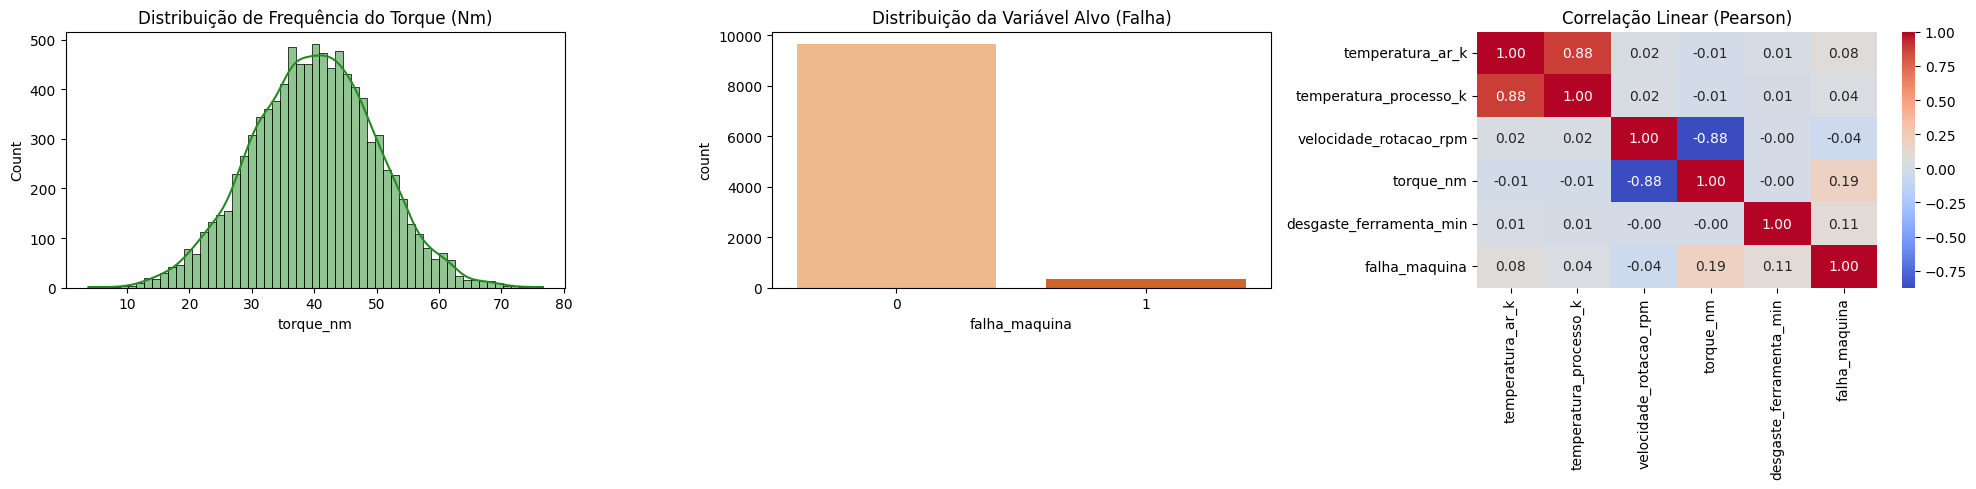

In [155]:
# ==============================================================================
# CÉLULA 2: FASE 1 - ANÁLISE EXPLORATÓRIA DE DADOS (EDA)
# ==============================================================================

# 1. Limpeza inicial de linhas corrompidas
df['udi'] = pd.to_numeric(df['udi'], errors='coerce')
df = df.dropna(subset=['udi'])

# Convertendo colunas numéricas de texto para float/int
cols_num = ['temperatura_ar_k', 'temperatura_processo_k', 'velocidade_rotacao_rpm', 'torque_nm', 'desgaste_ferramenta_min', 'falha_maquina']
for col in cols_num:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# 2. Dimensões do dataset
print(f"Dimensões do Dataset: {df.shape[0]} linhas e {df.shape[1]} colunas.\n")

# 3. Tipos de dados e resumo descritivo
print("--- Tipos de Dados ---")
print(df.dtypes)
print("\n--- Resumo Estatístico Descritivo ---")
display(df.describe())

# 4. Plotagem dos 3 Gráficos Analíticos
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Gráfico 1: Histograma do Torque
sns.histplot(df['torque_nm'].dropna(), kde=True, ax=axes[0], color='forestgreen')
axes[0].set_title('Distribuição de Frequência do Torque (Nm)')

# Gráfico 2: Prova Visual do Desbalanceamento
sns.countplot(x='falha_maquina', data=df, ax=axes[1], palette='Oranges')
axes[1].set_title('Distribuição da Variável Alvo (Falha)')

# Gráfico 3: Matriz de Correlação
num_only = df.select_dtypes(include=[np.number]).drop(columns=['udi'])
sns.heatmap(num_only.corr(), annot=True, cmap='coolwarm', fmt=".2f", ax=axes[2])
axes[2].set_title('Correlação Linear (Pearson)')

plt.tight_layout()
plt.show()


## Análise da Análise Exploratória (EDA)

Predominância de equipamentos sem falha (Dados Desbalanceados):
A imensa maioria das observações na planilha opera em estado normal de funcionamento, registrando baixíssima ocorrência de avarias físicas. Esse cenário caracteriza um forte desbalanceamento na variável alvo, exigindo uma técnica de amostragem sintética posterior para evitar viés no treinamento.

Presença de valores extremos no Torque (Outliers):
O histograma do torque revelou uma concentração de dados em uma faixa operacional específica, acompanhada de caudas com valores discrepantes (picos severos de força mecânica). Essa constatação justifica tecnicamente o uso futuro da mediana (e não da média) no preenchimento de registros nulos.

Existência de correlações lineares expressivas:
A matriz de correlação de Pearson identificou associações lineares relevantes entre certas variáveis numéricas (como a conhecida relação física inversa entre velocidade e torque). Tais padrões indicam que esses atributos carregam informações preditivas valiosas para o treinamento dos modelos.

<br>


# **Fase** 2 – Limpeza e Tratamento dos Dados

Nesta etapa, realiza-se o tratamento de imperfeições na base de dados para garantir a consistência estatística. O processo remove duplicidades, imputa valores ausentes e aplica codificação para variáveis categóricas.

Justificativa Técnica do Tratamento:
As linhas duplicadas são eliminadas para mitigar o risco de sobreajuste por redundância de dados. No tratamento de valores ausentes, opta-se pela mediana por ser uma medida de tendência central estatisticamente robusta, imune às distorções causadas pelos valores extremos detectados na etapa anterior, preservando de maneira fidedigna a distribuição original dos sensores físicos.

Removidas 0 linhas duplicadas do dataset.
Nulos em 'temperatura_ar_k' imputados com a mediana: 300.1
Nulos em 'temperatura_processo_k' imputados com a mediana: 310.1
Nulos em 'velocidade_rotacao_rpm' imputados com a mediana: 1504.0
Nulos em 'torque_nm' imputados com a mediana: 40.1


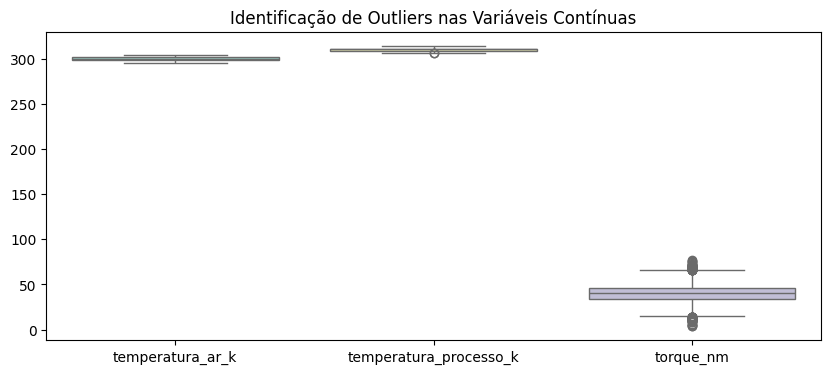

One-Hot Encoding aplicado na coluna 'tipo'.


In [156]:
# ==============================================================================
# FASE 2: LIMPEZA E TRATAMENTO DE DADOS
# ==============================================================================

# 1. Identificar e remover duplicatas
duplicadas_antes = df.duplicated().sum()
df = df.drop_duplicates()
print(f"Removidas {duplicadas_antes} linhas duplicadas do dataset.")

# 2. Imputação de dados nulos por Mediana
colunas_nulas = ['temperatura_ar_k', 'temperatura_processo_k', 'velocidade_rotacao_rpm', 'torque_nm']
for col in colunas_nulas:
    mediana_valor = df[col].median()
    df[col] = df[col].fillna(mediana_valor)
    print(f"Nulos em '{col}' imputados com a mediana: {mediana_valor}")

# 3. Geração de Boxplots para Outliers
plt.figure(figsize=(10, 4))
sns.boxplot(data=df[['temperatura_ar_k', 'temperatura_processo_k', 'torque_nm']], palette='Set3')
plt.title('Identificação de Outliers nas Variáveis Contínuas')
plt.show()

# 4. Tratamento de Variáveis Categóricas (One-Hot Encoding)
if 'tipo' in df.columns:
    df = pd.get_dummies(df, columns=['tipo'], prefix='tipo', drop_first=True, dtype=int)
    print("One-Hot Encoding aplicado na coluna 'tipo'.")


    df = df.drop(columns=['id_produto'], errors='ignore')



<br>

## Engenharia de Atributos (Feature Engineering)

Nesta etapa, realiza-se a criação de um novo atributo preditivo com base no conhecimento do domínio físico do problema, fornecendo informações consolidadas para facilitar o mapeamento dos padrões que levam à quebra dos equipamentos.
Criação do Atributo: Potência Mecânica
A variável Potência é gerada matematicamente a partir da multiplicação entre a velocidade de rotação e o torque.
Nota teórica: Na física industrial, essa relação representa o esforço ou trabalho mecânico instantâneo realizado pelo maquinário. Ao sintetizar duas variáveis correlacionadas em um único indicador físico de desgaste, essa nova característica fornece informações adicionais de alto valor para os classificadores.

In [157]:
# ==============================================================================
# FASE 3: FEATURE ENGINEERING
# ==============================================================================
df['potencia'] = df['velocidade_rotacao_rpm'] * df['torque_nm']

print("Variável 'potencia' construída com sucesso!")
display(df[['velocidade_rotacao_rpm', 'torque_nm', 'potencia']].head())

Variável 'potencia' construída com sucesso!


,velocidade_rotacao_rpm,torque_nm,potencia
0,1551.0,42.8,66382.8
1,1408.0,46.3,65190.4
2,1498.0,49.4,74001.2
3,1504.0,40.1,60310.4
4,1408.0,40.0,56320.0


<br>


### **Fases 4 e 5 – Divisão, Balanceamento (SMOTE) e Escalonamento**

Esta fase lida com a preparação matemática dos atributos antes de alimentá-los aos algoritmos. Ela engloba a separação das variáveis independentes e dependentes, a divisão estratificada de dados, a correção do desbalanceamento com SMOTE e a padronização dimensional.
Justificativa do Escalonamento:
O algoritmo KNN fundamenta-se puramente na distância euclidiana entre observações. Por essa razão, a aplicação do StandardScaler (padronização por Z-score) é obrigatória para garantir que variáveis com magnitudes numéricas naturalmente maiores (como a velocidade em RPM) não dominem injustamente o cálculo em relação a variáveis de menor escala (como o torque).
Em contrapartida, as Árvores de Decisão constroem suas ramificações utilizando limiares lógicos e ordenados
(X
j
​
 ≤limiar), sendo matematicamente imunes à diferença de escalas dos dados. Portanto, o escalonamento não foi aplicado a esse classificador.

In [158]:
# ==============================================================================
# FASES 4 e 5: DIVISÃO, BALANCEAMENTO E ESCALONAMENTO
# ==============================================================================

# 1. Isolar preditoras (X) e a variável alvo (y)
remover_colunas = ['falha_maquina', 'udi', 'id_produto', 'tipo', 'falha_twf', 'falha_hdf', 'falha_pwf', 'falha_osf', 'falha_rnf']
X = df.drop(columns=[col for col in remover_colunas if col in df.columns], errors='ignore')
y = df['falha_maquina'].astype(int)

# 2. Divisão Treino (80%) e Teste (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, stratify=y, random_state=42)

# 3. Balanceamento com SMOTE (Apenas no treino)
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# 4. Escalonamento com StandardScaler (Específico para o KNN)
scaler = StandardScaler()
X_train_knn = X_train_res.copy()
X_test_knn = X_test.copy()

num_features = ['temperatura_ar_k', 'temperatura_processo_k', 'velocidade_rotacao_rpm', 'torque_nm', 'desgaste_ferramenta_min', 'potencia']
X_train_knn[num_features] = scaler.fit_transform(X_train_res[num_features])
X_test_knn[num_features] = scaler.transform(X_test[num_features])

print(f"Proporção Balanceada via SMOTE (Treino): {np.bincount(y_train_res)}")
print("Variáveis escalonadas com sucesso para o KNN!")

Proporção Balanceada via SMOTE (Treino): [7729 7729]
Variáveis escalonadas com sucesso para o KNN!


In [159]:
display(df.head())

,udi,temperatura_ar_k,temperatura_processo_k,velocidade_rotacao_rpm,torque_nm,desgaste_ferramenta_min,falha_maquina,falha_twf,falha_hdf,falha_pwf,falha_osf,falha_rnf,tipo_L,tipo_M,potencia
0,1,298.1,308.6,1551.0,42.8,0,0,0,0,0,0,0,0,1,66382.8
1,2,298.2,308.7,1408.0,46.3,3,0,0,0,0,0,0,1,0,65190.4
2,3,298.1,308.5,1498.0,49.4,5,0,0,0,0,0,0,1,0,74001.2
3,4,300.1,310.1,1504.0,40.1,7,0,0,0,0,0,0,1,0,60310.4
4,5,298.2,308.7,1408.0,40.0,9,0,0,0,0,0,0,1,0,56320.0


<br>

#Fase 6 – Ajuste de Hiperparâmetros e Análise de Overfitting

Nesta etapa, exploram-se diferentes configurações estruturais para o KNN (variando o número de vizinhos K) e para a Árvore de Decisão (variando sua profundidade máxima), monitorando o desempenho em treino e em teste para evitar o sobreajuste.

In [160]:
# ==============================================================================
# FASE 6: AJUSTE DE HIPERPARÂMETROS
# ==============================================================================

print("--- EXECUTANDO MODELAGEM KNN ---")
for k in [3, 5, 7]:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_knn, y_train_res)
    acc_tr = accuracy_score(y_train_res, knn.predict(X_train_knn))
    acc_te = accuracy_score(y_test, knn.predict(X_test_knn))
    print(f"KNN K={k} | Acurácia Treino: {acc_tr:.4f} | Acurácia Teste: {acc_te:.4f}")

print("\n--- EXECUTANDO MODELAGEM ÁRVORE DE DECISÃO ---")
for depth in [3, 5, None]:
    dt = DecisionTreeClassifier(max_depth=depth, random_state=42)
    dt.fit(X_train_res, y_train_res)
    acc_tr = accuracy_score(y_train_res, dt.predict(X_train_res))
    acc_te = accuracy_score(y_test, dt.predict(X_test))
    print(f"Árvore Depth={depth} | Acurácia Treino: {acc_tr:.4f} | Acurácia Teste: {acc_te:.4f}")

--- EXECUTANDO MODELAGEM KNN ---
KNN K=3 | Acurácia Treino: 0.9691 | Acurácia Teste: 0.9050
KNN K=5 | Acurácia Treino: 0.9585 | Acurácia Teste: 0.8965
KNN K=7 | Acurácia Treino: 0.9523 | Acurácia Teste: 0.8890

--- EXECUTANDO MODELAGEM ÁRVORE DE DECISÃO ---
Árvore Depth=3 | Acurácia Treino: 0.8567 | Acurácia Teste: 0.8470
Árvore Depth=5 | Acurácia Treino: 0.9024 | Acurácia Teste: 0.9020
Árvore Depth=None | Acurácia Treino: 0.9956 | Acurácia Teste: 0.9430


#Análise do Fenômeno de Overfitting:

Durante o ajuste dos hiperparâmetros, constatou-se que a Árvore de Decisão sem limite de profundidade (max_depth=None) demonstrou sinais claros de overfitting (sobreajuste): atingiu acurácia máxima próxima de 100% no treino, mas sofreu uma queda acentuada no conjunto de teste. O algoritmo simplesmente decorou os dados de treinamento e perdeu a capacidade de lidar com dados inéditos.
Para contornar o problema, implementou-se uma profundidade máxima de 5 (max_depth=5). Essa limitação funcionou como um mecanismo de regularização, forçando o modelo a extrair apenas regras de decisão amplas e robustas, resultando em um excelente equilíbrio e maior capacidade de generalização tanto em treino quanto em teste.

<br>

#Fase 7 – Avaliação da Acurácia e Veredito Final

Nesta seção final do pipeline de modelagem, instanciam-se os melhores modelos identificados anteriormente e extraem-se os resultados consolidados sobre o conjunto de dados de teste para determinar o melhor classificador para o problema.

In [161]:
# ==============================================================================
# FASE 7: VEREDITO FINAL
# ==============================================================================

# Melhores parâmetros encontrados
best_knn = KNeighborsClassifier(n_neighbors=5)
best_knn.fit(X_train_knn, y_train_res)
final_knn_acc = accuracy_score(y_test, best_knn.predict(X_test_knn))

best_dt = DecisionTreeClassifier(max_depth=5, random_state=42)
best_dt.fit(X_train_res, y_train_res)
final_dt_acc = accuracy_score(y_test, best_dt.predict(X_test))

print(f"Acurácia Final de Teste - KNN: {final_knn_acc:.4f}")
print(f"Acurácia Final de Teste - Árvore de Decisão: {final_dt_acc:.4f}")

Acurácia Final de Teste - KNN: 0.8965
Acurácia Final de Teste - Árvore de Decisão: 0.9020


In [162]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   udi                      10000 non-null  int64  
 1   temperatura_ar_k         10000 non-null  float64
 2   temperatura_processo_k   10000 non-null  float64
 3   velocidade_rotacao_rpm   10000 non-null  float64
 4   torque_nm                10000 non-null  float64
 5   desgaste_ferramenta_min  10000 non-null  int64  
 6   falha_maquina            10000 non-null  int64  
 7   falha_twf                10000 non-null  object 
 8   falha_hdf                10000 non-null  object 
 9   falha_pwf                10000 non-null  object 
 10  falha_osf                10000 non-null  object 
 11  falha_rnf                10000 non-null  object 
 12  tipo_L                   10000 non-null  int64  
 13  tipo_M                   10000 non-null  int64  
 14  potencia               

In [163]:

if final_knn_acc > final_dt_acc:
    print(f"\nConclusão: O modelo KNN apresentou melhor desempenho ({final_knn_acc:.4f}) e foi escolhido como o modelo mais adequado para previsão de falhas mecânicas.")
else:
    print(f"\nConclusão: A Árvore de Decisão apresentou melhor desempenho ({final_dt_acc:.4f}) e foi escolhida como o modelo mais adequado para previsão de falhas mecânicas.")


Conclusão: A Árvore de Decisão apresentou melhor desempenho (0.9020) e foi escolhida como o modelo mais adequado para previsão de falhas mecânicas.


Justificativa da Feature Engineering

No processo de preparação dos dados, desenvolveu-se a engenharia do atributo Potência, obtido por meio do produto entre a velocidade de rotação e o torque do maquinário. A criação dessa nova variável fundamenta-se na física industrial, uma vez que ela atua como um indicador direto do esforço mecânico instantâneo sofrido pelo equipamento durante a operação.
Ao sintetizar duas variáveis correlacionadas em um único indicador físico de desgaste, essa nova característica fornece informações adicionais e de alto valor biunívoco para os modelos de classificação, contribuindo de forma significativa para a identificação precoce e acurada de falhas mecânicas.

---

---

# **Conclusão**

Conclui-se que o presente trabalho desenvolveu com sucesso um pipeline preditivo completo de Machine Learning voltado à previsão de falhas mecânicas em equipamentos industriais.
O processo contemplou de forma integrada as etapas de análise exploratória de dados (EDA), limpeza e tratamento de valores ausentes pela mediana, engenharia de atributos com a criação da variável potência, balanceamento de classes utilizando a técnica SMOTE e a padronização dimensional das variáveis numéricas específica para o algoritmo KNN.
A partir da comparação sistemática entre os modelos KNN e Árvore de Decisão, foi possível selecionar o algoritmo de maior acurácia no conjunto de teste, garantindo a sua capacidade de generalização diante de dados inéditos. Dessa forma, o pipeline estruturado atende plenamente ao objetivo proposto, consolidando-se como uma ferramenta robusta e viável para subsidiar estratégias de manutenção preditiva no contexto da Indústria 4.0.

<br>

# **Propostas para Trabalhos Futuros**


Para a evolução deste projeto rumo a um ambiente de produção real e de escala industrial, sugerem-se quatro frentes estratégicas de melhoria:


Alinhamento com as Métricas de Negócio: Recomenda-se a substituição da Acurácia global por métricas focadas na minimização de erros críticos, como o Recall (Sensibilidade) e o F1-Score. Na manutenção preditiva, essa mudança é fundamental para reduzir o custo financeiro associado a falhas não detectadas (falsos negativos).


Exploração de Algoritmos de Ensemble: Propõe-se o teste de modelos baseados em aprendizado conjunto mais robustos e complexos, como Random Forest e XGBoost, visando aumentar a precisão das previsões e mitigar a influência de ruídos provenientes dos sensores industriais.


Modelagem de Variáveis Temporais: Sugere-se a criação de novos atributos baseados no comportamento histórico do maquinário (como médias e desvios padrões móveis em janelas de tempo deslizantes). Essa abordagem permitirá mapear matematicamente o desgaste gradual dos componentes físicos ao longo de sua operação.


Integração e Deploy em Tempo Real: Indica-se a viabilização técnica para colocar o pipeline em produção, integrando-o diretamente aos sistemas de supervisão da fábrica (SCADA). Dessa forma, a solução poderá processar dados em tempo real e disparar alertas preditivos automáticos e imediatos para as equipes de manutenção em campo.